1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

2. Load Dataset

In [12]:
data = pd.read_csv(r"C:\Users\Smart-tech\Desktop\Tweets.csv")
data.columns = data.columns.str.strip()
data.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


3. Missing Values Handle And Select Columns

In [3]:
data = data.dropna(subset=['text'])
data['text'] = data['text'].astype(str)
texts = data['text']
labels = data['sentiment']


5. Encode Labels

In [4]:
le = LabelEncoder()
y = le.fit_transform(labels)

6. Text Preprocessing

In [5]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=100)

7. Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

8. RNN Model

In [7]:
rnn_model = Sequential()
rnn_model.add(Embedding(input_dim=5000, output_dim=64, input_length=100))
rnn_model.add(SimpleRNN(64))
rnn_model.add(Dense(3, activation='softmax'))

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("\nTraining RNN Model...")
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Training RNN Model...
Epoch 1/5


C:\Users\Smart-tech\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


687/687 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.5464 - loss: 0.9235 - val_accuracy: 0.6443 - val_loss: 0.7991
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.7477 - loss: 0.6214 - val_accuracy: 0.6567 - val_loss: 0.7996
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.8490 - loss: 0.4110 - val_accuracy: 0.6603 - val_loss: 0.9105
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.9193 - loss: 0.2358 - val_accuracy: 0.6416 - val_loss: 1.1476
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.9486 - loss: 0.1560 - val_accuracy: 0.6181 - val_loss: 1.4145


9. LSTM Model

In [8]:
lstm_model = Sequential()
lstm_model.add(Embedding(input_dim=5000, output_dim=64, input_length=100))
lstm_model.add(LSTM(64))
lstm_model.add(Dense(3, activation='softmax'))

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("\nTraining LSTM Model...")
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Training LSTM Model...
Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 35s 46ms/step - accuracy: 0.6308 - loss: 0.8107 - val_accuracy: 0.7018 - val_loss: 0.6955
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 32s 47ms/step - accuracy: 0.7520 - loss: 0.6060 - val_accuracy: 0.7149 - val_loss: 0.6765
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 30s 44ms/step - accuracy: 0.7864 - loss: 0.5323 - val_accuracy: 0.7154 - val_loss: 0.6878
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - accuracy: 0.8142 - loss: 0.4741 - val_accuracy: 0.7143 - val_loss: 0.7121
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - accuracy: 0.8395 - loss: 0.4211 - val_accuracy: 0.7049 - val_loss: 0.7634


10. Evaluation

In [9]:
print("\nEvaluating Models...")

rnn_loss, rnn_acc = rnn_model.evaluate(X_test, y_test)
lstm_loss, lstm_acc = lstm_model.evaluate(X_test, y_test)

print("\n===== Final Result =====")
print("RNN Accuracy :", rnn_acc)
print("LSTM Accuracy:", lstm_acc)


Evaluating Models...
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6181 - loss: 1.4145
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7049 - loss: 0.7634

===== Final Result =====
RNN Accuracy : 0.6180858612060547
LSTM Accuracy: 0.7048762440681458


11. Graphs

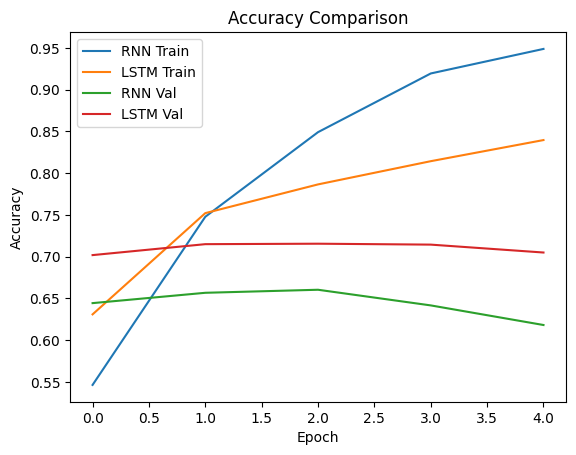

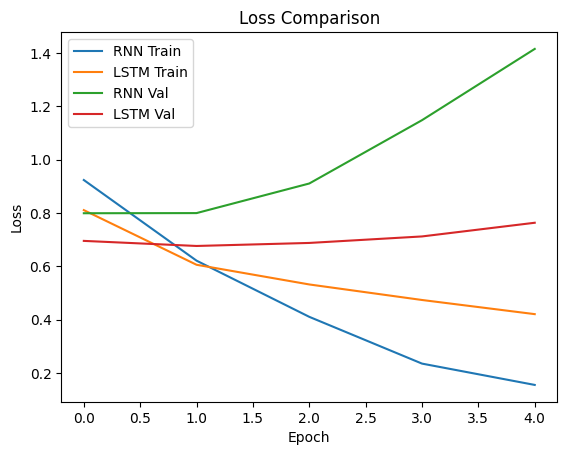

In [10]:

plt.figure()
plt.plot(rnn_history.history['accuracy'])
plt.plot(lstm_history.history['accuracy'])
plt.plot(rnn_history.history['val_accuracy'])
plt.plot(lstm_history.history['val_accuracy'])
plt.title('Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['RNN Train', 'LSTM Train', 'RNN Val', 'LSTM Val'])
plt.show()

# Loss Graph
plt.figure()
plt.plot(rnn_history.history['loss'])
plt.plot(lstm_history.history['loss'])
plt.plot(rnn_history.history['val_loss'])
plt.plot(lstm_history.history['val_loss'])
plt.title('Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['RNN Train', 'LSTM Train', 'RNN Val', 'LSTM Val'])
plt.show()